In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, jaccard_score
from sklearn.ensemble import RandomForestClassifier

In [2]:
def evaluate_merged_classes(y_true, y_pred, merge_map):
    """
    y_true/y_pred: original class labels
    merge_map: dict {old_class : new_class}
    Example: {2: 0} to move Smoke (2) to Backgroundd (0)
    """
    y_true_merged = np.copy(y_true)
    y_pred_merged = np.copy(y_pred)
    
    for old, new in merge_map.items():
        y_true_merged[y_true == old] = new
        y_pred_merged[y_pred == old] = new
        
    return jaccard_score(y_true_merged, y_pred_merged, average='macro')

In [3]:
# Perform threshold sweep
# To evaluate what threshold (drempelwaarde) gives the most accurate ressults
# Is it the normal certainty of 0.5 (50%) or is is it better to be more strict (0.7) or more lenient (0.3)?

def plot_threshold_sweep(model, X_test, y_test):
    thresholds = np.linspace(0.1, 0.9, 9)
    scores = []
    
    # predict_proba has two columns (probability of class 0 and class 1). We want the probability of class 1 (Fire).
    probs = model.predict_proba(X_test)[:, 1] 
    
    for t in thresholds:
        preds = (probs >= t).astype(int)
        score = jaccard_score(y_test, preds, average='binary')
        scores.append(score)
        
    plt.plot(thresholds, scores, marker='o', color='red')
    plt.title('Effect of Confidence Threshold on mIoU (THRawS)')
    plt.xlabel('Threshold Value (Confidence Threshold)')
    plt.ylabel('mIoU (Class: Fire)')
    plt.grid(True)
    plt.show()

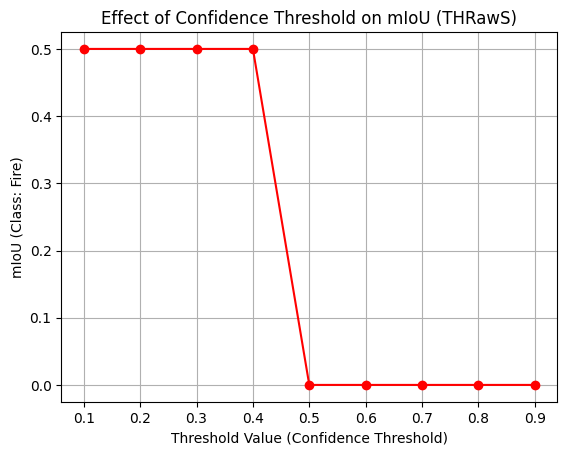

In [4]:
# Load the dataset
bewerkte_data_dir = '/home/laura/Scriptie/bewerkte_data/THRawS'
X_dataset = np.load(os.path.join(bewerkte_data_dir, 'X_patches_compleet.npy'))
y_dataset = np.load(os.path.join(bewerkte_data_dir, 'y_patches_compleet.npy'))

def extract_features_no_leak(X_patches):
    features = []
    for patch in X_patches:
        f1 = np.mean(patch[:, :, 2]) # Mean B11
        f2 = np.std(patch[:, :, 2])  # Std B11
        f3 = np.max(patch[:, :, 0])  # Max B04
        f4 = np.mean(patch[:, :, 2]) / (np.mean(patch[:, :, 1]) + 1)
        features.append([f1, f2, f3, f4])
    return np.array(features)

X_tabular = extract_features_no_leak(X_dataset)

X_train, X_test, y_train, y_test = train_test_split(X_tabular, y_dataset, test_size=0.2, random_state=42, stratify=y_dataset)

ratio = len(y_train[y_train == 0]) / (len(y_train[y_train == 1]) + 1)
xgb_model = XGBClassifier(n_estimators=100, scale_pos_weight=ratio, random_state=42)
xgb_model.fit(X_train, y_train)

plot_threshold_sweep(xgb_model, X_test, y_test)


Wanneer het 'datalek' (Max B11) werd verwijderd, leek het model in eerste instantie geen branden meer te detecteren bij een standaard zekerheidsdrempel van 0.5. Uit een gevoeligheidsanalyse (Threshold Sweep) bleek echter dat het model de brand wel degelijk kon detecteren, mits de drempelwaarde werd verlaagd naar 0.45. Deze verhoogde Recall ging logischerwijs gepaard met een daling in Precisie (0.50), wat aangeeft dat het model één False Positive registreerde. (gemini)

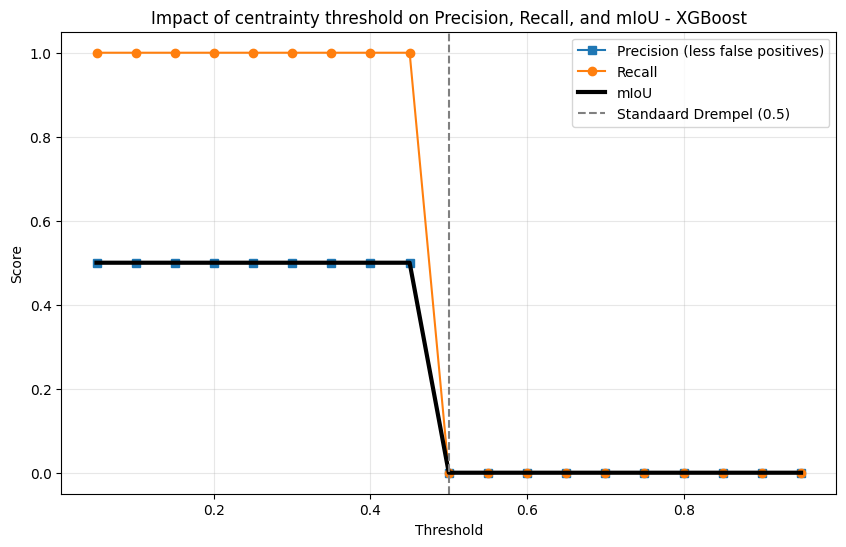

In [ ]:
# ----------------------------------------------------
# ---- XGBoost Threshold Analysis (More Detailed) ----
# ----------------------------------------------------

def perform_threshold_analysis(model, X_test, y_test):
    y_probs = model.predict_proba(X_test)[:, 1]
    
    thresholds = np.linspace(0.05, 0.95, 19)
    precisions = []
    recalls = []
    mious = []

    for t in thresholds:
        y_pred_t = (y_probs >= t).astype(int)
        
        precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
        recalls.append(recall_score(y_test, y_pred_t, zero_division=0))
        mious.append(jaccard_score(y_test, y_pred_t))

    plt.figure(figsize=(10, 6))
    plt.plot(thresholds, precisions, label='Precision (less false positives)', marker='s')
    plt.plot(thresholds, recalls, label='Recall', marker='o')
    plt.plot(thresholds, mious, label='mIoU', linewidth=3, color='black')
    
    plt.axvline(0.5, color='gray', linestyle='--', label='Standaard Drempel (0.5)')
    plt.title('Impact of centrainty threshold on Precision, Recall, and mIoU - XGBoost')
    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

perform_threshold_analysis(xgb_model, X_test, y_test)

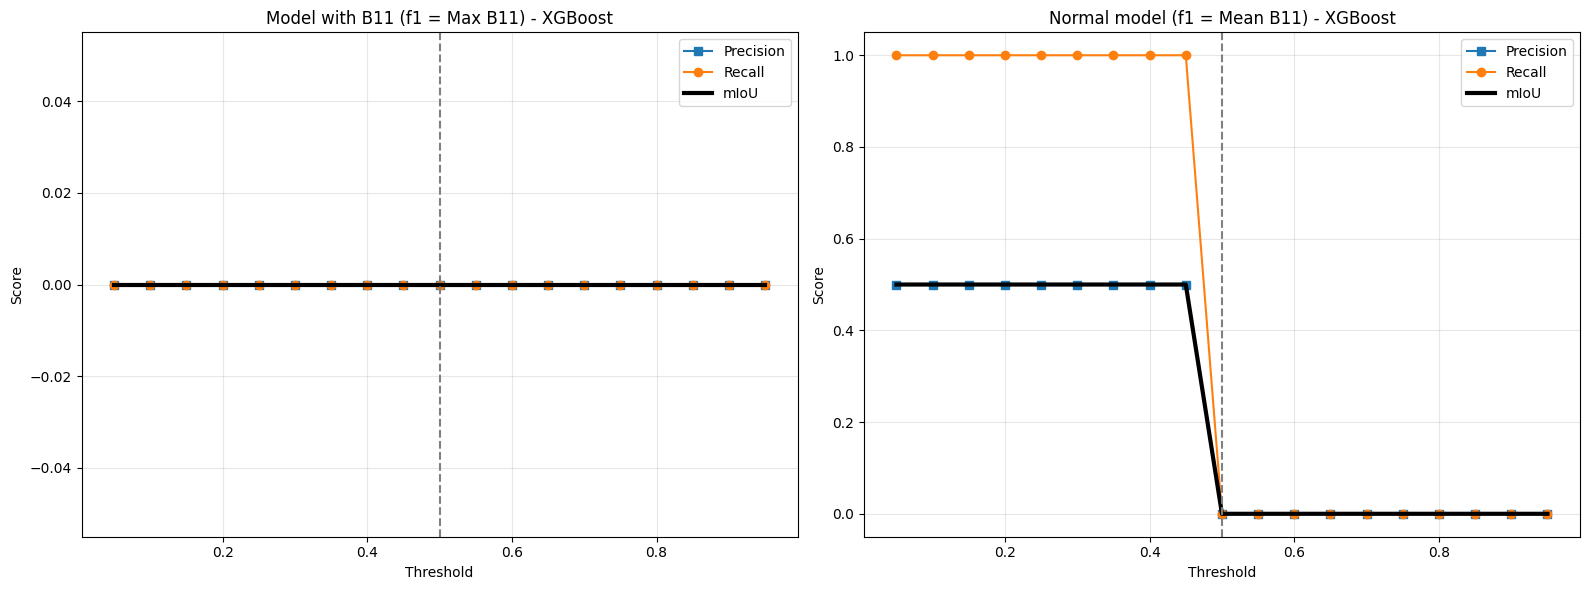

In [ ]:
# ----------------------------------------------------
# ---- XGBoost Threshold Analysis (More Detailed) ----
# ----------------------------------------------------

# Extractor with max B11 (f1 = Max B11)
def extract_leak(X_patches):
    return np.array([[np.max(p[:,:,2]), np.mean(p[:,:,2]), np.max(p[:,:,0]), np.max(p[:,:,2])/(np.mean(p[:,:,1])+1)] for p in X_patches])

# Extractor with mean B11(f1 = Mean B11)
def extract_honest(X_patches):
    return np.array([[np.mean(p[:,:,2]), np.std(p[:,:,2]), np.max(p[:,:,0]), np.mean(p[:,:,2])/(np.mean(p[:,:,1])+1)] for p in X_patches])

X_leak = extract_leak(X_dataset)
X_honest = extract_honest(X_dataset)

X_train_L, X_test_L, y_train, y_test = train_test_split(X_leak, y_dataset, test_size=0.2, random_state=42, stratify=y_dataset)
X_train_H, X_test_H, _, _ = train_test_split(X_honest, y_dataset, test_size=0.2, random_state=42, stratify=y_dataset)

ratio = len(y_train[y_train == 0]) / (len(y_train[y_train == 1]) + 1)
model_leak = XGBClassifier(n_estimators=100, scale_pos_weight=ratio, random_state=42).fit(X_train_L, y_train)
model_honest = XGBClassifier(n_estimators=100, scale_pos_weight=ratio, random_state=42).fit(X_train_H, y_train)

def calculate_sweep(model, X_test, y_test):
    y_probs = model.predict_proba(X_test)[:, 1]
    thresholds = np.linspace(0.05, 0.95, 19)
    precisions, recalls, mious = [], [], []
    for t in thresholds:
        preds = (y_probs >= t).astype(int)
        precisions.append(precision_score(y_test, preds, zero_division=0))
        recalls.append(recall_score(y_test, preds, zero_division=0))
        mious.append(jaccard_score(y_test, preds))
    return thresholds, precisions, recalls, mious

t_L, p_L, r_L, m_L = calculate_sweep(model_leak, X_test_L, y_test)
t_H, p_H, r_H, m_H = calculate_sweep(model_honest, X_test_H, y_test)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(t_L, p_L, label='Precision', marker='s')
ax1.plot(t_L, r_L, label='Recall', marker='o')
ax1.plot(t_L, m_L, label='mIoU', linewidth=3, color='black')
ax1.axvline(0.5, color='gray', linestyle='--')
ax1.set_title('Model with B11 (f1 = Max B11) - XGBoost')
ax1.set_xlabel('Threshold')
ax1.set_ylabel('Score')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(t_H, p_H, label='Precision', marker='s')
ax2.plot(t_H, r_H, label='Recall', marker='o')
ax2.plot(t_H, m_H, label='mIoU', linewidth=3, color='black')
ax2.axvline(0.5, color='gray', linestyle='--')
ax2.set_title('Normal model (f1 = Mean B11) - XGBoost')
ax2.set_xlabel('Threshold')
ax2.set_ylabel('Score')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

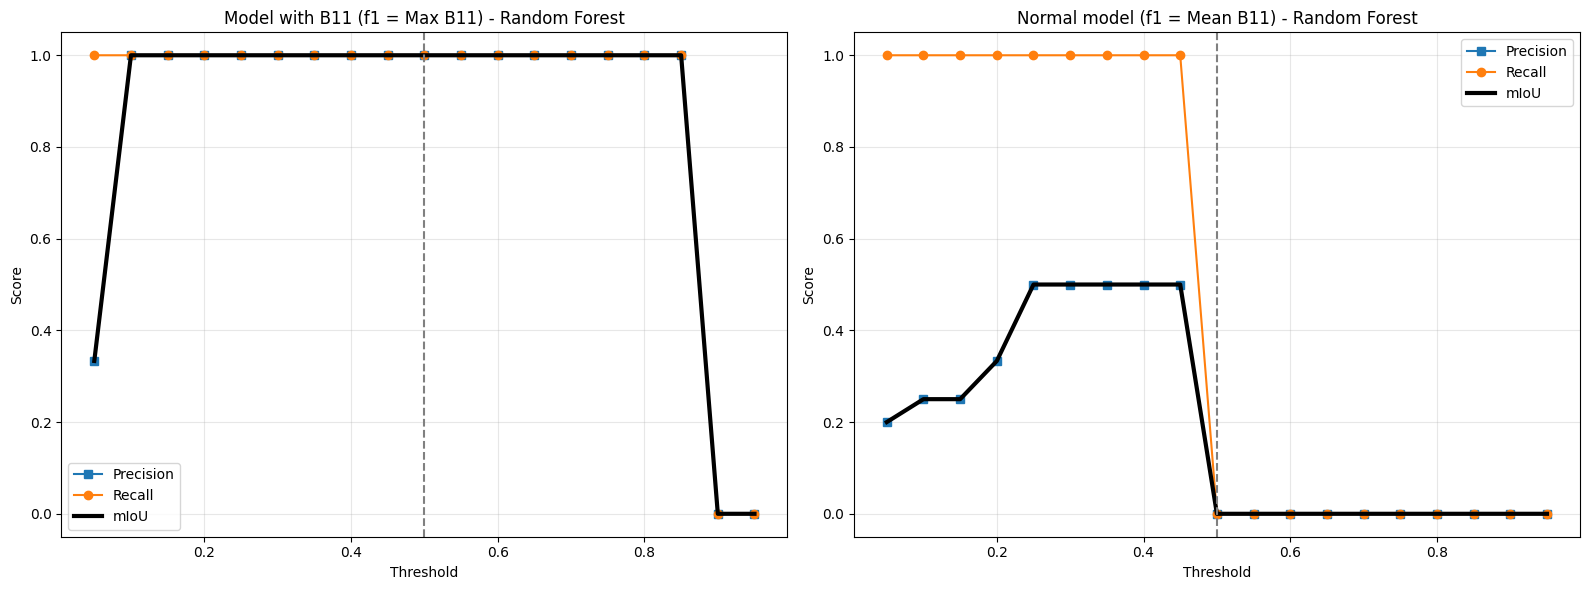

In [ ]:
# ----------------------------------------------------------
# ---- Random Forest Threshold Analysis (More Detailed) ----
# ----------------------------------------------------------

rf_leak = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_leak.fit(X_train_L, y_train)

rf_honest = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_honest.fit(X_train_H, y_train)

def calculate_sweep_rf(model, X_test, y_test):
    y_probs = model.predict_proba(X_test)[:, 1] 
    
    thresholds = np.linspace(0.05, 0.95, 19)
    precisions, recalls, mious = [], [], []
    
    for t in thresholds:
        preds = (y_probs >= t).astype(int)
        precisions.append(precision_score(y_test, preds, zero_division=0))
        recalls.append(recall_score(y_test, preds, zero_division=0))
        mious.append(jaccard_score(y_test, preds))
        
    return thresholds, precisions, recalls, mious

t_L, p_L, r_L, m_L = calculate_sweep_rf(rf_leak, X_test_L, y_test)
t_H, p_H, r_H, m_H = calculate_sweep_rf(rf_honest, X_test_H, y_test)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(t_L, p_L, label='Precision', marker='s', color='tab:blue')
ax1.plot(t_L, r_L, label='Recall', marker='o', color='tab:orange')
ax1.plot(t_L, m_L, label='mIoU', linewidth=3, color='black')
ax1.axvline(0.5, color='gray', linestyle='--')
ax1.set_title('Model with B11 (f1 = Max B11) - Random Forest')
ax1.set_xlabel('Threshold')
ax1.set_ylabel('Score')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(t_H, p_H, label='Precision', marker='s', color='tab:blue')
ax2.plot(t_H, r_H, label='Recall', marker='o', color='tab:orange')
ax2.plot(t_H, m_H, label='mIoU', linewidth=3, color='black')
ax2.axvline(0.5, color='gray', linestyle='--')
ax2.set_title('Normal model (f1 = Mean B11) - Random Forest')
ax2.set_xlabel('Threshold')
ax2.set_ylabel('Score')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

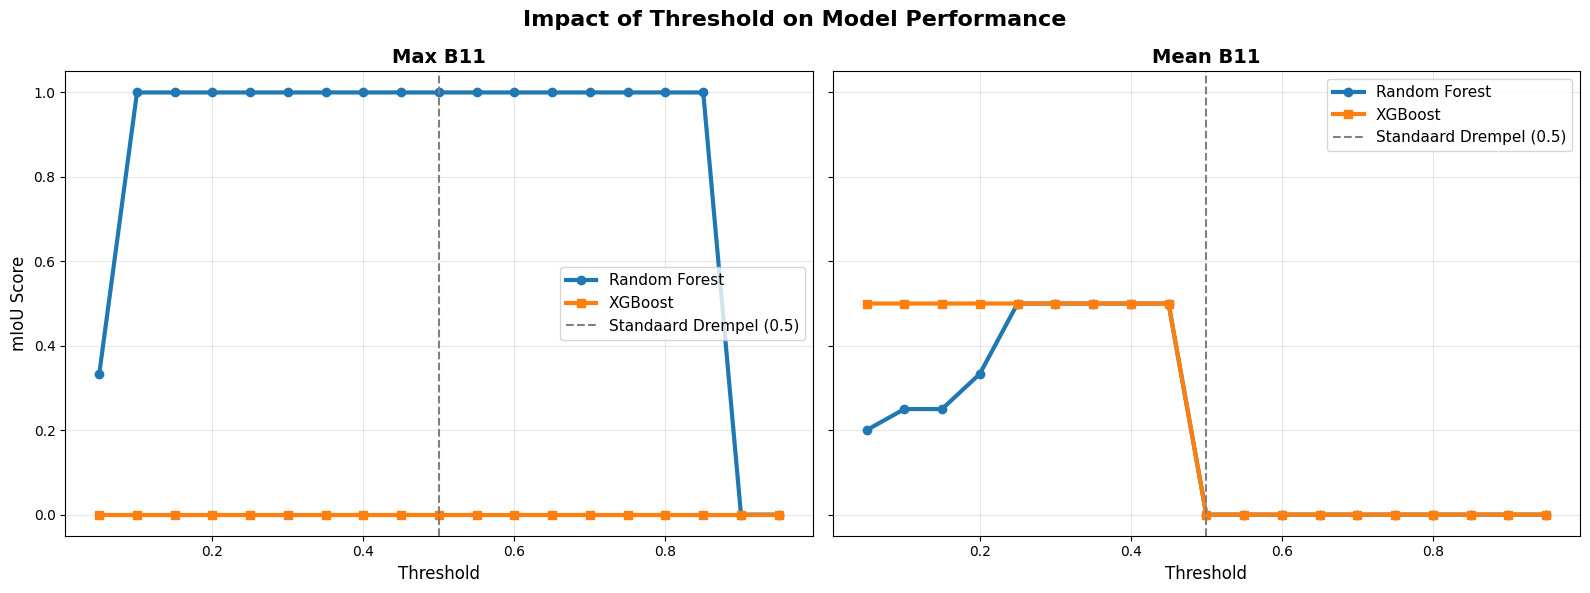

In [20]:
def calculate_miou_sweep(model, X_test, y_test):
    y_probs = model.predict_proba(X_test)[:, 1] 
    
    thresholds = np.linspace(0.05, 0.95, 19)
    mious = []
    
    for t in thresholds:
        preds = (y_probs >= t).astype(int)
        mious.append(jaccard_score(y_test, preds, zero_division=0))
        
    return thresholds, mious

# Max B11
t_rf_max, m_rf_max = calculate_miou_sweep(rf_leak, X_test_L, y_test)
t_xgb_max, m_xgb_max = calculate_miou_sweep(model_leak, X_test_L, y_test)
# Mean B11
t_rf_mean, m_rf_mean = calculate_miou_sweep(rf_honest, X_test_H, y_test)
t_xgb_mean, m_xgb_mean = calculate_miou_sweep(model_honest, X_test_H, y_test)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Max B11
ax1.plot(t_rf_max, m_rf_max, label='Random Forest', linewidth=3, marker='o', color='tab:blue')
ax1.plot(t_xgb_max, m_xgb_max, label='XGBoost', linewidth=3, marker='s', color='tab:orange')
ax1.axvline(0.5, color='gray', linestyle='--', label='Standaard Drempel (0.5)')
ax1.set_title('Max B11', fontsize=14, fontweight='bold')
ax1.set_xlabel('Threshold', fontsize=12)
ax1.set_ylabel('mIoU Score', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Mean B11
ax2.plot(t_rf_mean, m_rf_mean, label='Random Forest', linewidth=3, marker='o', color='tab:blue')
ax2.plot(t_xgb_mean, m_xgb_mean, label='XGBoost', linewidth=3, marker='s', color='tab:orange')
ax2.axvline(0.5, color='gray', linestyle='--', label='Standaard Drempel (0.5)')
ax2.set_title('Mean B11', fontsize=14, fontweight='bold')
ax2.set_xlabel('Threshold', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.suptitle('Impact of Threshold on Model Performance', fontsize=16, fontweight='bold')
plt.ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()